# Transfer Learning on Audio - Environmental Sound Classification

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Load Model

In [2]:
# Load YAMNet model from TensorFlow Hub
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

In [3]:
# Function to create waveform (1s at 16kHz)
def generate_sine_wave(freq, duration=1.0, sr=16000):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    waveform = 0.5 * np.sin(2 * np.pi * freq * t)
    return waveform.astype(np.float32)

# Load Dataset

In [4]:
# Generate labeled dataset
def create_synthetic_audio_dataset():
    freqs = [200, 400, 800]  # simulate 3 classes
    waveforms = []
    labels = []
    for i, f in enumerate(freqs):
        for _ in range(15):
            wave = generate_sine_wave(f) + 0.01 * np.random.randn(16000).astype(np.float32)
            waveforms.append(wave)
            labels.append(i)
    return np.array(waveforms), np.array(labels)

# Prepare data

In [5]:
# Prepare data
X_wave, y = create_synthetic_audio_dataset()

# Extract Embedding

In [7]:
# Extract embeddings using YAMNet
@tf.function
def extract_embeddings(waveform):
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return tf.reduce_mean(embeddings, axis=0)  # mean-pooling

X_embed = []
for wave in X_wave:
    # Reshape to (16000,) instead of (1, 16000)
    wav_tensor = tf.convert_to_tensor(wave.reshape(-1))
    emb = extract_embeddings(wav_tensor)
    X_embed.append(emb.numpy())

X_embed = np.array(X_embed)

# Classifier Training

In [8]:
# Train a classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_embed, y)
pred = clf.predict(X_embed)
acc = accuracy_score(y, pred)
print(f"Train Accuracy: {acc:.2f}")

Train Accuracy: 1.00


# Confusion Matrix

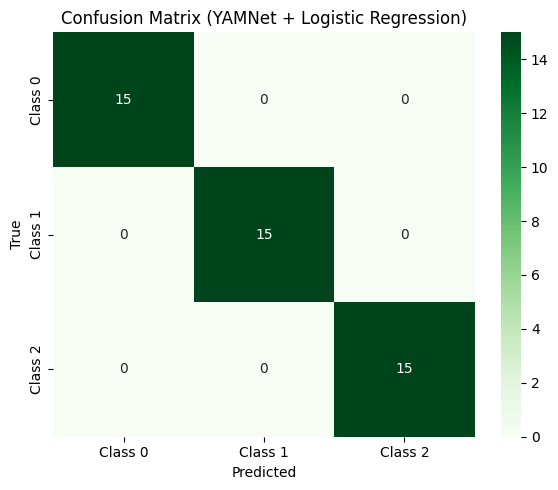

In [9]:
# Confusion Matrix
cm = confusion_matrix(y, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Greens', xticklabels=["Class 0", "Class 1", "Class 2"], yticklabels=["Class 0", "Class 1", "Class 2"])
plt.title("Confusion Matrix (YAMNet + Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# t-SNE Visualization

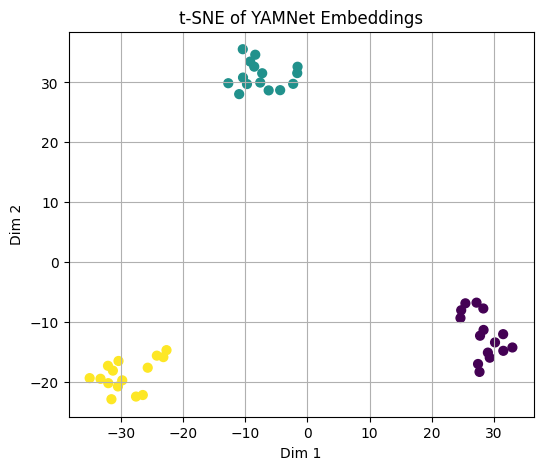

In [10]:
# t-SNE Visualization
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(X_embed)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='viridis', s=40)
plt.title("t-SNE of YAMNet Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()